# Comparing Word Learning in Children and Language Models: A Data Science Case Study
##### *Author: Slavena Peneva-Kargiou*  
##### *Course: SoftUni Data Science* 
##### *Instructor: Yordan Darakchiev*
##### *Date: 26 April 2026*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from collections import Counter
import re
import os

# 1. Introduction
My previous project in this series looked at a phoneme-triggered word recall in my two trilingual children - how many words they could produce starting with a given sound, accross Bulgarian, Greek and English. That project used linear algebra and statistics to find structure in something I had been watching informally for years.

This project starts from a similar place but asks a bigger question. My children are learning language the way all children do - through play, repetition, emotion, pointing at things, hearing the same words in different contexts, falling off bikes, meeting dogs, watching their grandmother cook. A language model learns from text. Just text, nothing else.

Both are, in some sense, learning from the same raw material. But do they end up knowing the same words? Do they learn them in the same order? And if not, what does the gap tell us about the difference between human and machine learning?

I will try to answer these questions combining three datasets: Wordbank, the largest empirical database of children's vocabulary acquisition accross languages; the BabyLM corpus, a carefully curated collection of child-directed speech used to train language models; and the Brysbaert concreteness ratings, a large scale dataset of 40 000 English words rating them on how concrete or abstract they are. Together, the three datasets allow a direct data-driven comparison between what children learn, what a language model is exposed to, and where the two diverge.

# 2. The Two Learners

## 2.1 How a Child Learns Words
Children learning their first words are not passively absorbing frequency statistics. Long before they can speak, they are tracking faces, following pointing fingers, associating sounds with objects that matter to them - the bottle, the ball, the parent, etc. I have watched this process up close with my own two children and what really impressed me is how purposeful it all seems - the words that come first are the ones that are useful, concrete and repeatedly connected to something in the physical world. Hence words like "Mummy", "water", "more", "no" usually come long before words like "the", "of", "because".

This process is well documented by the MacArthur-Bated Communicative Development Inventory (CDI), the instrument behind the Wordbank database used in this project. By 18 months most children have a vocabulary of around 50 words. By 30 months that number has typically exploded to several hundred. The order in which words are acquired is surprisingly consistent accross children and even accross languages - concrete nouns and social words come first, abstract grammatical words come last.

## 2.2 How a Language Model Learns Words
Language models, on the other hand, have no bodies, no pointing fingers, no emotional response to the word "Mummy". What they have is large quantities of text and the ability to learn statistical patterns from it. Their only signal for how important a word is, is how often it appears and in what contexts. A word that appears frequently and in different contexts, becomes well represented in the model's internal structure. A word that appears rarely remains poorly represented.

The BabyLM challenge, launched in 2023 and updated subsequently in 2024, 2025 and 2026, asks a pointed question: what happens if you train a language model on roughly the same amount of text a child hears in the first years of their life. The resulting models are outstanding for their data size, but they still learn from text alone, with no access to the embodied, social, emotional world a child inhabits.

## 2.3 The Comparison
The gap between these two learners is the subject of this project. If frequency was all that mattered, a language model and a child should learn words in roughly the same order - the most frequent words first. If frequency is not enough, we would expect the two orderings to diverge, and the pattern of divergence could tell us something about what children have that language models don't.

# 3. The Datasets

## 3.1. Wordbank 
Wordbank (wordbank.stanford.edu) is the largest open repository of children's vocabulary development data in the world. It aggregates responses from the MacArthur-Bates Communicative Development Inventory (CDI), a parent report instrument in which caregivers indicate which words their child understands and/or produces from a standardized checklist. The database currently contains data from 92 771 children accross 42 languages.

For this project I use the English (American) Words & Sentences (WS) form, which covers children aged 16 to 30 months - the window in which most of the early vocabulary explosion occurs. Each word in the dataset has a proportion value for each age in months: the fraction of children in the sample who were reported to produce that word at that age. From these proportions I derive the Age of Acquisition (AoA) for each word - defined as the youngest age at which at least 50% of children produce it. 

The dataset contains 680 words accross 21 semantic categories, from animals and food to pronouns, quantifiers and connecting words. Of these, 569 reach the 50% threshold within the 16-30 month window and are assigned an AoA value. The remaining 111 words are still being learned at 30 months and are excluded from the AoA analysis.

## 3.2 BabyLM Corpus
The BabyLM corpus was created for the BabyLM Challenge, a shared task that was launched in 2023 and updated in 2024, 2025 and 2026, which invites researchers to train language models on developmentally plausible amounts of text - roughly what a child is exposed to in the first years of life. The corpus is a carefully curated collection of child-directed and child-adjacent text, including transcripts from CHILDES (the Child Language Data Exchange System), children's books, subtitles and spoken language corpora.

I use the 10 million word version of the corpus, available on HuggingFace. This represents approximately the amount of language input a child receives in the first three years of life - a deliberate design choice by the BabyLM organizers to make the comparison between child and model learning as direct as possible. From this corpus I compute three word-level statistics: raw frequency (how many times the word appears), mean utterance length (the average length of utterances the word appears in), and utterance diversity (how many distinct utterances contain the word). These three measures together represent what a language model trained on this corpus knows about a word.

## 3.3. Brysbaert Concreteness Ratings
The Brysbaert et al.(2014) concreteness ratings dataset provides mean concreteness scores for 37 058 English words and 2 896 two-word expressions collected from over 4000 participants who rated each word on a 1-5 scale, from fully abstract (1) to fully concrete (5). For example, a word like "dog" receives a score close to 5, while a word like "justice" receives a score close to 1.

Concreteness is included here as a third dimension precisely because it is a human cognitive property - it reflects the degree to which a word refers to something that can be perceived, touched, or pointed at. A language model has no access to concreteness in any direct sense, it can only infer it indirectly from the statistical patterns in text. By including concreteness alongside corpus frequency, we can ask whether the properties a model can learn from text are sufficient to explain children's word learning, or whether something beyond text is needed. 

## 3.4 Loading the data

In [3]:
project_dir = os.path.expanduser('~/Desktop/Softuni-Data-Science-Final-Project')

# Loading the three datasets
df_wordbank  = pd.read_csv(os.path.join(project_dir, 'wordbank_item_data.csv'))
df_babylm    = pd.read_csv(os.path.join(project_dir, 'babylm_10M.csv'))
df_concrete  = pd.read_excel(os.path.join(project_dir, 'Concreteness_ratings_Brysbaert_et_al_BRM.xlsx'))

print("=== Wordbank ===")
print(f"Shape: {df_wordbank.shape}")
display(df_wordbank.head(3))

print("\n=== BabyLM ===")
print(f"Shape: {df_babylm.shape}")
display(df_babylm.head(3))

print("\n=== Brysbaert Concreteness ===")
print(f"Shape: {df_concrete.shape}")
display(df_concrete.head(3))

=== Wordbank ===
Shape: (680, 19)


,downloaded,item_id,item_definition,category,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
0,2026-03-28,1,baa baa,sounds,0.46,0.52,0.55,0.66,0.69,0.70,0.66,0.78,0.78,0.78,0.79,0.82,0.89,0.80,0.79
1,2026-03-28,2,choo choo,sounds,0.27,0.32,0.39,0.51,0.56,0.60,0.67,0.71,0.76,0.84,0.81,0.85,0.92,0.85,0.88
2,2026-03-28,3,cockadoodledoo,sounds,0.13,0.10,0.14,0.22,0.22,0.29,0.31,0.37,0.43,0.45,0.49,0.53,0.70,0.54,0.58



=== BabyLM ===
Shape: (1058713, 1)


,text
0,aboo .
1,kee .
2,hey .



=== Brysbaert Concreteness ===
Shape: (39954, 9)


,Word,Bigram,Conc.M,Conc.SD,Unknown,Total,Percent_known,SUBTLEX,Dom_Pos
0,roadsweeper,0,4.85,0.37,1,27,0.962963,0,0
1,traindriver,0,4.54,0.71,3,29,0.896552,0,0
2,tush,0,4.45,1.01,3,25,0.880000,66,0


# 4. Data Processing and Merging

## 4.1 Computing AoA from Wordbank Proportions
Each word in the Wordbank dataset has a proportion value for each age in months - the fraction of children producing that word at that age. To derive a single AoA value per word, I find the youngest age at which this proportion first reaches or exceeds 0.50 (50%). Words that never reach this threshold within the 16-30 month window are assigned NaN and are excluded from the analysis.

In [4]:
age_cols = ['16','17','18','19','20','21','22','23','24','25','26','27','28','29','30']

def compute_aoa(row, threshold=0.5):
    """Return the first age (months) at which >= 50% of children produce the word."""
    for age in age_cols:
        if row[age] >= threshold:
            return int(age)
    return np.nan

df_wordbank['aoa'] = df_wordbank.apply(compute_aoa, axis=1)
df_wordbank['word'] = df_wordbank['item_definition'].str.lower().str.strip()
df_aoa = df_wordbank[['word', 'category', 'aoa']].copy()

print(f"Words with AoA defined (reach 50%): {df_aoa['aoa'].notna().sum()}")
print(f"Words never reaching 50% within window: {df_aoa['aoa'].isna().sum()}")
display(df_aoa.head(10))

Words with AoA defined (reach 50%): 569
Words never reaching 50% within window: 111


,word,category,aoa
0,baa baa,sounds,17.0
1,choo choo,sounds,19.0
2,cockadoodledoo,sounds,27.0
3,grrr,sounds,16.0
4,meow,sounds,18.0
5,moo,sounds,16.0
6,ouch,sounds,19.0
7,quack quack,sounds,19.0
8,uh oh,sounds,16.0
9,vroom,sounds,18.0


## 4.2 Computing Word Statistics from BabyLM
From the raw BabyLM corpus I compute three statistics for each word: frequency, mean utterance length and utterance diversity. These three measures together represent the full learning signal available to a language model trained on this corpus.

In [5]:
# Drop NaN rows
df_babylm = df_babylm.dropna(subset=['text'])
print(f"BabyLM utterances after cleaning: {len(df_babylm):,}")

word_counts = Counter()
word_utterance_lengths = {}
word_utterance_sets = {}

for text in df_babylm['text']:
    words = re.findall(r'\b[a-z]+\b', text.lower())
    utt_len = len(words)
    utt_text = text.lower().strip()
    for word in set(words):
        word_counts[word] += 1
        if word not in word_utterance_lengths:
            word_utterance_lengths[word] = []
            word_utterance_sets[word] = set()
        word_utterance_lengths[word].append(utt_len)
        word_utterance_sets[word].add(utt_text)

df_freq = pd.DataFrame({
    'word':               list(word_counts.keys()),
    'frequency':          list(word_counts.values()),
    'mean_utt_length':    [np.mean(word_utterance_lengths[w]) for w in word_counts],
    'utterance_diversity':[len(word_utterance_sets[w]) for w in word_counts]
})

print(f"Unique words in corpus: {len(df_freq):,}")
print(f"Total word tokens: {df_freq['frequency'].sum():,}")
display(df_freq.sort_values('frequency', ascending=False).head(10))

BabyLM utterances after cleaning: 1,015,493
Unique words in corpus: 135,605
Total word tokens: 8,614,586


,word,frequency,mean_utt_length,utterance_diversity
16,the,252047,21.667026,245919
31,you,176459,10.999365,154556
64,i,170603,12.557581,153282
58,to,166199,23.884253,161664
123,a,159269,24.018566,154686
208,and,159129,26.950839,156140
292,of,142454,27.547089,139598
32,it,126065,19.217015,115363
19,s,121839,17.413907,108782
86,in,119684,29.234793,117372


## 4.3 Preparing the Concreteness Dataset

In [6]:
df_concrete_clean = df_concrete[['Word', 'Conc.M']].copy()
df_concrete_clean.columns = ['word', 'concreteness']
df_concrete_clean['word'] = df_concrete_clean['word'].str.lower().str.strip()

print(f"Concreteness ratings: {len(df_concrete_clean):,} words")
print(f"Score range: {df_concrete_clean['concreteness'].min():.2f} – "
      f"{df_concrete_clean['concreteness'].max():.2f}")
display(df_concrete_clean.head(5))

Concreteness ratings: 39,954 words
Score range: 1.04 – 5.00


,word,concreteness
0,roadsweeper,4.85
1,traindriver,4.54
2,tush,4.45
3,hairdress,3.93
4,pharmaceutics,3.77


## 4.4 Merging the Three Datasets
The three datasets are merged on the word as a common key. Because Wordbank contains only early childhood vocabulary (680 words) while the BabyLM corpus contains 135 605 unique tokens and Brysbaert covers nearly 40 000 words, the merge is left-joined on Wordbank - every Wordbank word is kept and corpus and concreteness values are added where available.

In [7]:
df_merged = df_aoa\
    .merge(df_freq, on='word', how='left')\
    .merge(df_concrete_clean, on='word', how='left')

print(f"Total Wordbank words:          {len(df_merged)}")
print(f"With frequency data:           {df_merged['frequency'].notna().sum()}")
print(f"With concreteness data:        {df_merged['concreteness'].notna().sum()}")
print(f"With all three variables:      "
      f"{df_merged[['aoa','frequency','concreteness']].notna().all(axis=1).sum()}")

# Final analysis dataset — words with all three variables defined
df_analysis = df_merged[
    df_merged['aoa'].notna() &
    df_merged['frequency'].notna() &
    df_merged['concreteness'].notna()
].copy().reset_index(drop=True)

print(f"\nFinal analysis dataset: {len(df_analysis)} words")
display(df_analysis.head(10))

Total Wordbank words:          680
With frequency data:           593
With concreteness data:        588
With all three variables:      473

Final analysis dataset: 473 words


,word,category,aoa,frequency,mean_utt_length,utterance_diversity,concreteness
0,meow,sounds,18.0,53.0,4.943396,21.0,3.92
1,moo,sounds,16.0,49.0,14.693878,40.0,3.40
2,ouch,sounds,19.0,78.0,4.653846,39.0,2.76
3,alligator,animals,27.0,44.0,20.386364,40.0,4.96
4,animal,animals,25.0,745.0,37.348993,732.0,4.61
5,ant,animals,26.0,39.0,41.974359,39.0,4.86
6,bear,animals,21.0,928.0,30.796336,881.0,4.88
7,bee,animals,23.0,161.0,28.720497,152.0,4.88
8,bird,animals,19.0,734.0,38.344687,708.0,5.00
9,bug,animals,23.0,134.0,18.962687,125.0,5.00


Among the 87 words missing from the corpus, there are mainly multy-word entries such as "baa baa", "choo choo" and "uh oh" - onomatopoeia and sound words that appear as compound tokens in Wordbank but are not tokenized as single words in the corpus. This is an interesting finding - the words most characteristic of child-directed speech are the ones that are least well represented in the model's training data.

# 5. Exploratory Data Analysis

## 5.1 Wordbank - AoA Distribution and Category Breakdown

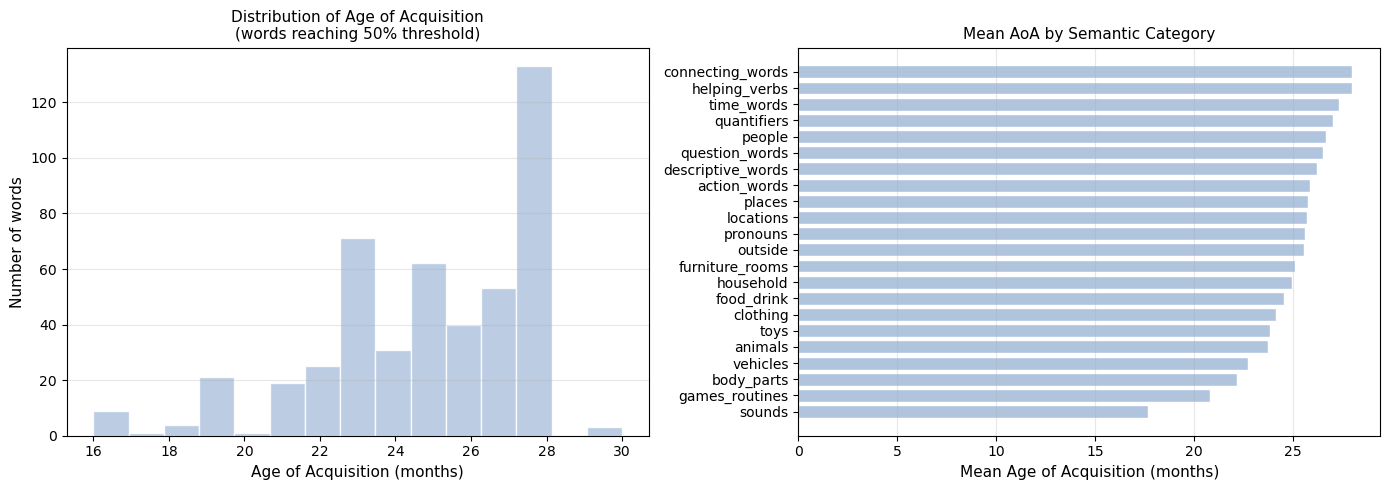


AoA summary statistics:
count    473.00
mean      24.97
std        2.96
min       16.00
25%       23.00
50%       25.00
75%       28.00
max       30.00
Name: aoa, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AoA distribution
axes[0].hist(df_analysis['aoa'], bins=15, color='lightsteelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Age of Acquisition (months)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Distribution of Age of Acquisition\n(words reaching 50% threshold)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Mean AoA by category
cat_aoa = df_analysis.groupby('category')['aoa'].mean().sort_values()
axes[1].barh(cat_aoa.index, cat_aoa.values, color='lightsteelblue',
             edgecolor='white')
axes[1].set_xlabel('Mean Age of Acquisition (months)', fontsize=11)
axes[1].set_title('Mean AoA by Semantic Category', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAoA summary statistics:")
print(df_analysis['aoa'].describe().round(2))

The mean AoA across the 473 words in the analysis dataset is 24.97 months, with most words learned in the second half of the  child's second year. The category chart show the expected pattern: sounds and games_routines are learned earliest, while connecting_words, helping_words and time_words are learned last. This ordering of concrete and social words first and abstract and grammatical words last is the corpus against which the corpus measures will be compared.

## 5.2 BabyLM - Frequency Distribution and Zipf's Law
One of the most well-known properties of natural language is Zipf's law - word frequency follows a power law distribution where a small number of words account for the vast majority of occurencies. A language model trained on such a corpus sees some words thousands of times and most words only rarely. This is the fundamental assymetry that makes frequency a poor learning signal for rare but important words.

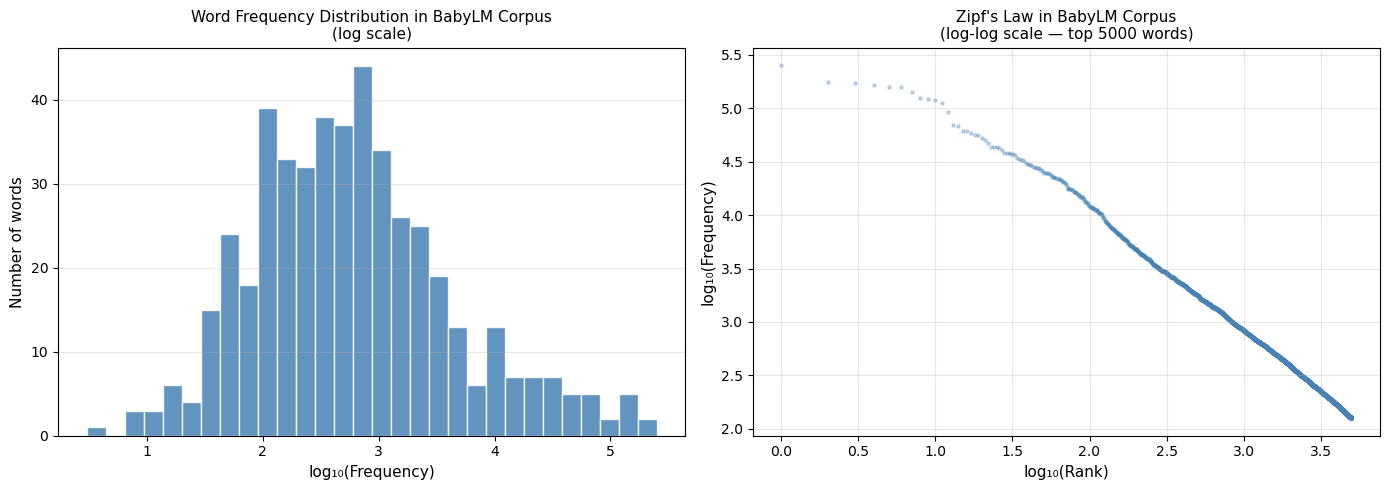


Frequency summary statistics (analysis dataset):
count       473.00
mean       6207.73
std       23621.99
min           2.00
25%         138.00
50%         506.00
75%        1750.00
max      252047.00
Name: frequency, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency distribution (log scale)
axes[0].hist(np.log10(df_analysis['frequency'] + 1), bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log₁₀(Frequency)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Word Frequency Distribution in BabyLM Corpus\n(log scale)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Zipf's law: rank vs frequency on log-log scale
freq_sorted = df_freq.sort_values('frequency', ascending=False).reset_index(drop=True)
freq_sorted['rank'] = freq_sorted.index + 1

axes[1].scatter(np.log10(freq_sorted['rank'][:5000]),
                np.log10(freq_sorted['frequency'][:5000]),
                alpha=0.3, s=5, color='steelblue')
axes[1].set_xlabel('log₁₀(Rank)', fontsize=11)
axes[1].set_ylabel('log₁₀(Frequency)', fontsize=11)
axes[1].set_title("Zipf's Law in BabyLM Corpus\n(log-log scale — top 5000 words)",
                  fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFrequency summary statistics (analysis dataset):")
print(df_analysis['frequency'].describe().round(2))

Word frequencies in the corpus span from 2 to 252 047 occurencies which is a highly uneven learning signal. The Zipf's law plot confirms the classic power law pattern: a small number of words dominate the corpus while the majority appear rarely. This means the model's exposure to different words varies enormously even within the relatively small child directed dataset.

## 5.3 Brysbaert - Concreteness Distribution

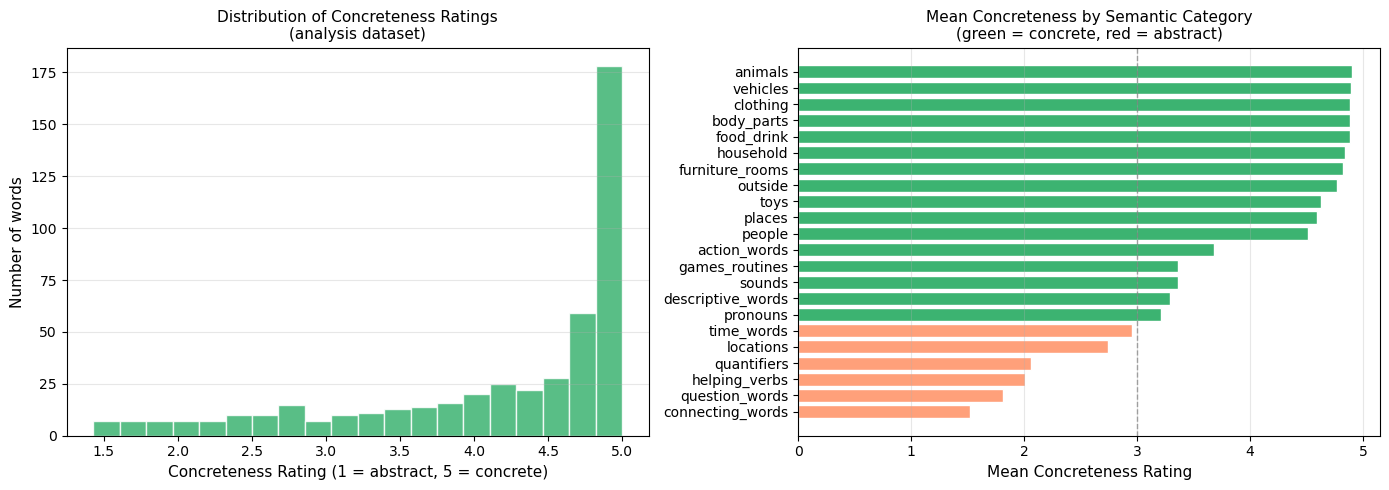


Concreteness summary statistics:
count    473.00
mean       4.17
std        0.97
min        1.43
25%        3.71
50%        4.67
75%        4.90
max        5.00
Name: concreteness, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall concreteness distribution
axes[0].hist(df_analysis['concreteness'], bins=20,
             color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Concreteness Rating (1 = abstract, 5 = concrete)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Distribution of Concreteness Ratings\n(analysis dataset)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Mean concreteness by category
cat_concrete = df_analysis.groupby('category')['concreteness'].mean().sort_values()
colors = ['lightsalmon' if v < 3 else 'mediumseagreen' for v in cat_concrete.values]
axes[1].barh(cat_concrete.index, cat_concrete.values, color=colors,
             edgecolor='white')
axes[1].axvline(3, color='grey', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Mean Concreteness Rating', fontsize=11)
axes[1].set_title('Mean Concreteness by Semantic Category\n'
                  '(green = concrete, red = abstract)', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConcreteness summary statistics:")
print(df_analysis['concreteness'].describe().round(2))

The concreteness distribution is strongly skewed toward concrete words with a mean of 4.17 and a spike at 5.0 containing 177 words. The category chart shows a clean split: all physical object categories score above 4.5, while abstract grammatical categories fall below 2.5. This bimodal structure will become central to the hypothesis test in Section 7.

## 5.4 What Getls Lost in the Merge and Why

In [12]:
# Words missing from corpus
missing_corpus = df_merged[df_merged['frequency'].isna()]['word'].tolist()
missing_concrete = df_merged[df_merged['concreteness'].isna() &
                              df_merged['frequency'].notna()]['word'].tolist()

print(f"Words missing from BabyLM corpus ({len(missing_corpus)}):")
print(missing_corpus[:20])

print(f"\nWords in corpus but missing concreteness ratings ({len(missing_concrete)}):")
print(missing_concrete[:20])

Words missing from BabyLM corpus (87):
['baa baa', 'choo choo', 'cockadoodledoo', 'quack quack', 'uh oh', 'woof woof', 'yum yum', 'chicken (animal)', 'fish (animal)', 'teddybear', 'play dough', 'toy (object)', 'chicken (food)', 'drink (beverage)', 'fish (food)', 'french fries', 'green beans', 'ice cream', 'orange (food)', 'peanut butter']

Words in corpus but missing concreteness ratings (16):
['grrr', 'vroom', 'bubbles', 'beans', 'carrots', 'cheerios', 'grapes', 'jello', 'nuts', 'peas', 'beads', 'gloves', 'mittens', 'lips', 'keys', 'pattycake']


The words missing from the corpus are telling. They fall into several distinct groups:

Many of them are multi-word entries - "baa baa", "uh oh", "yum yum" - the playful repetitive onomatopoeic language that is most characteristic of caregiver speech to young children. These words are among the earliest learned in Wordbank, yet they are invisible to the corpus based model because they do not tokenize as single words. 

We also have compound expressions ("ice cream", "french fries", "belly button"), as well as social routines and phrases ("give me five", "so big!") that ate multi-word and exist in the corpus only as separate tokens.

There are also some colloquial contractions like "gonna/going to", "wanna/want to", "lemme/let me" that appear in the corpus in their full form.

Another group that is particularly interesting is represented by entries like "fish (food)", "chicken (food)", "drink (beverage)". "Fish (food)" and "fish (animal)" are both stored as "fish" in the merged dataset, so only one entry survives the merge - the one that happens to appear first in Wordbank. The other is listed as missing from the corpus, but it is not really missing. It is just that the word-matching merge in this case has no way to distinguish between the two senses. The corpus contains "fish" plenty of times, but whether each of the occurrences refers to something you eat or something that swims is a question of context and not frequency. 

# 6. Comparison

## 6.1 Frequency vs Age of Acquisition
The central question of this project is whether a language model's primary learning signal, word frequency, predicts the order in which children learn words. To answer this, I compute Spearman rank correlation between each word's frequency rank in the BabyLM corpus and its AoA rank from Wordbank.

Spearman correlation is used rather than Pearson because both frequency and AoA are better treated as rankings rather than as continuous variables - AoA is measured in whole months and frequency follows a highly skewed power-law distribution. Spearman correlation measures whether the two rankings move together, regardless of the exact values.

In [15]:
# Add ranks to analysis dataset
df_analysis['aoa_rank']          = df_analysis['aoa'].rank(ascending=True)
df_analysis['freq_rank']         = df_analysis['frequency'].rank(ascending=False)
df_analysis['concreteness_rank'] = df_analysis['concreteness'].rank(ascending=False)
df_analysis['utt_length_rank']   = df_analysis['mean_utt_length'].rank(ascending=True)
df_analysis['diversity_rank']    = df_analysis['utterance_diversity'].rank(ascending=False)

# Spearman correlations
variables = {
    'Frequency':           'freq_rank',
    'Concreteness':        'concreteness_rank',
    'Utterance length':    'utt_length_rank',
    'Utterance diversity': 'diversity_rank'
}

print(f"{'Variable':<25} {'Spearman r':>12} {'p-value':>10}")
print("-" * 50)
for name, col in variables.items():
    r, p = spearmanr(df_analysis['aoa_rank'], df_analysis[col])
    print(f"{name:<25} {r:>12.3f} {p:>10.4f}")

Variable                    Spearman r    p-value
--------------------------------------------------
Frequency                       -0.007     0.8764
Concreteness                     0.302     0.0000
Utterance length                 0.128     0.0054
Utterance diversity             -0.016     0.7349


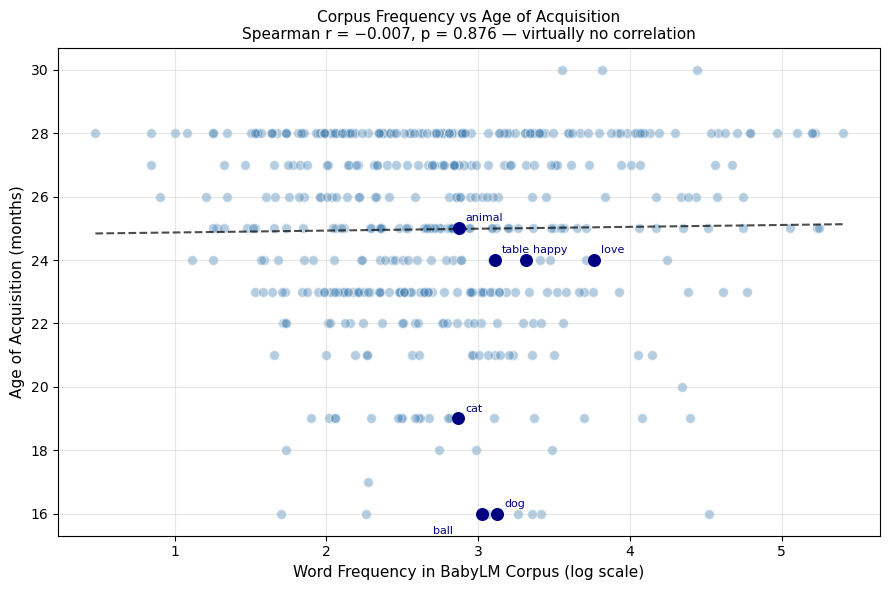

In [16]:
# Frequency vs AoA scatter
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(np.log10(df_analysis['frequency'] + 1), df_analysis['aoa'],
           alpha=0.4, color='steelblue', edgecolors='white', s=50)

highlight = ['dog', 'cat', 'ball', 'mummy', 'daddy', 'water',
             'table', 'animal', 'love', 'happy', 'if']
custom_offsets = {'ball': (-35, -15), 'dog': (5, 5)}
for word in highlight:
    row = df_analysis[df_analysis['word'] == word]
    if len(row) > 0:
        offset = custom_offsets.get(word, (5, 5))
        ax.annotate(word,
                   (np.log10(row['frequency'].values[0] + 1),
                    row['aoa'].values[0]),
                   fontsize=8, color='navy',
                   xytext=offset, textcoords='offset points')
        ax.scatter(np.log10(row['frequency'].values[0] + 1),
                  row['aoa'].values[0], color='navy', s=70, zorder=5)

m, b = np.polyfit(np.log10(df_analysis['frequency'] + 1),
                  df_analysis['aoa'], 1)
x_line = np.linspace(np.log10(df_analysis['frequency'] + 1).min(),
                     np.log10(df_analysis['frequency'] + 1).max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Word Frequency in BabyLM Corpus (log scale)', fontsize=11)
ax.set_ylabel('Age of Acquisition (months)', fontsize=11)
ax.set_title('Corpus Frequency vs Age of Acquisition\n'
             'Spearman r = −0.007, p = 0.876 — virtually no correlation',
             fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The result is unambiguous: Spearman r = -0.007, p = 0.8764. There is essentially no correlation between how often a word appears in child-directed speach and how early children learn it. The scatterplot makes this visually clear - the trendline is almost perfectly flat and words at every frequency level are distributed accross the full range of AoA values.

## 6.2 Concreteness vs Age of Acquisition

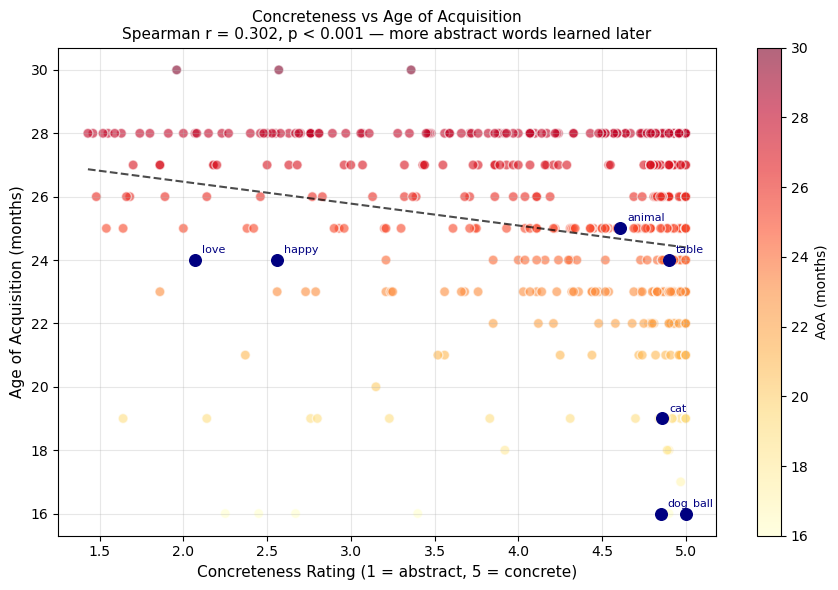

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(df_analysis['concreteness'], df_analysis['aoa'],
                     c=df_analysis['aoa'], cmap='YlOrRd',
                     alpha=0.6, edgecolors='white', s=50)

for word in highlight:
    row = df_analysis[df_analysis['word'] == word]
    if len(row) > 0:
        ax.annotate(word,
                   (row['concreteness'].values[0], row['aoa'].values[0]),
                   fontsize=8, color='navy',
                   xytext=(5, 5), textcoords='offset points')
        ax.scatter(row['concreteness'].values[0], row['aoa'].values[0],
                  color='navy', s=70, zorder=5)

m, b = np.polyfit(df_analysis['concreteness'], df_analysis['aoa'], 1)
x_line = np.linspace(df_analysis['concreteness'].min(),
                     df_analysis['concreteness'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Concreteness Rating (1 = abstract, 5 = concrete)', fontsize=11)
ax.set_ylabel('Age of Acquisition (months)', fontsize=11)
ax.set_title('Concreteness vs Age of Acquisition\n'
             'Spearman r = 0.302, p < 0.001 — more abstract words learned later',
             fontsize=11)
plt.colorbar(scatter, ax=ax, label='AoA (months)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Concreteness tells a different story: Spearman r = 0.302, p < 0.001. More abstract words are consistently learned later. Concrete words - dog, ball, cat, cluster at the bottom of the chart, learned at 16 to 19 months. Abstract words like love and happy sit at the top, as they are learned much later. The trendline slopes clearly downward.

Crucially, concreteness is not a property of the corpus, but a property of human cognition. A language model does not have direct access to it. It cannot know that "cat" refers to something you can touch, as opposed to "love". The fact that concreteness predicts AoA so much better than frequency could be used as evidence that children are using information that the models do not possess.

## 6.3 Utterance Length vs Age of Acquisition

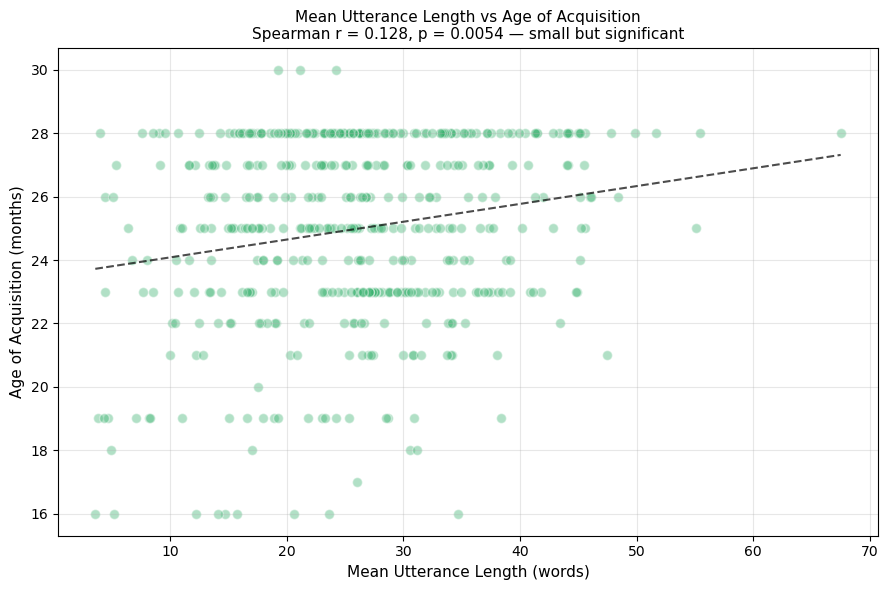

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_analysis['mean_utt_length'], df_analysis['aoa'],
           alpha=0.4, color='mediumseagreen', edgecolors='white', s=50)

m, b = np.polyfit(df_analysis['mean_utt_length'], df_analysis['aoa'], 1)
x_line = np.linspace(df_analysis['mean_utt_length'].min(),
                     df_analysis['mean_utt_length'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.7)

r, p = spearmanr(df_analysis['aoa_rank'], df_analysis['utt_length_rank'])
ax.set_xlabel('Mean Utterance Length (words)', fontsize=11)
ax.set_ylabel('Age of Acquisition (months)', fontsize=11)
ax.set_title(f'Mean Utterance Length vs Age of Acquisition\n'
             f'Spearman r = {r:.3f}, p = {p:.4f} — small but significant',
             fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Utterance length shows a small but statistically significant correlation with AoA (r = 0.128, p = 0.005). Words that appear in longer, more syntactically complex utterances tend to be learned later. This makes intuitive sense - simple words like "no", "more" and "up" are used in short direct utterances, while abstract words like "because" and "different" appear in longer and more complex sentences. This is one signal derived by the corpus that does carry some predictive value, though it is far weaker than concreteness.

## 6.4 Category Analysis

In [19]:
category_stats = df_analysis.groupby('category').agg(
    n_words        = ('word', 'count'),
    mean_aoa       = ('aoa', 'mean'),
    mean_freq_rank = ('freq_rank', 'mean'),
    mean_concrete  = ('concreteness', 'mean')
).round(2).sort_values('mean_aoa')

print("Category Statistics (sorted by mean AoA):")
display(category_stats)

Category Statistics (sorted by mean AoA):


,n_words,mean_aoa,mean_freq_rank,mean_concrete
category,,,,
sounds,3,17.67,419.83,3.36
games_routines,14,20.79,205.25,3.36
body_parts,20,22.15,240.82,4.88
vehicles,12,22.75,310.42,4.90
animals,38,23.74,327.39,4.90
toys,14,23.86,269.32,4.63
clothing,20,24.15,366.82,4.89
food_drink,46,24.57,359.10,4.88
household,42,24.98,299.52,4.84


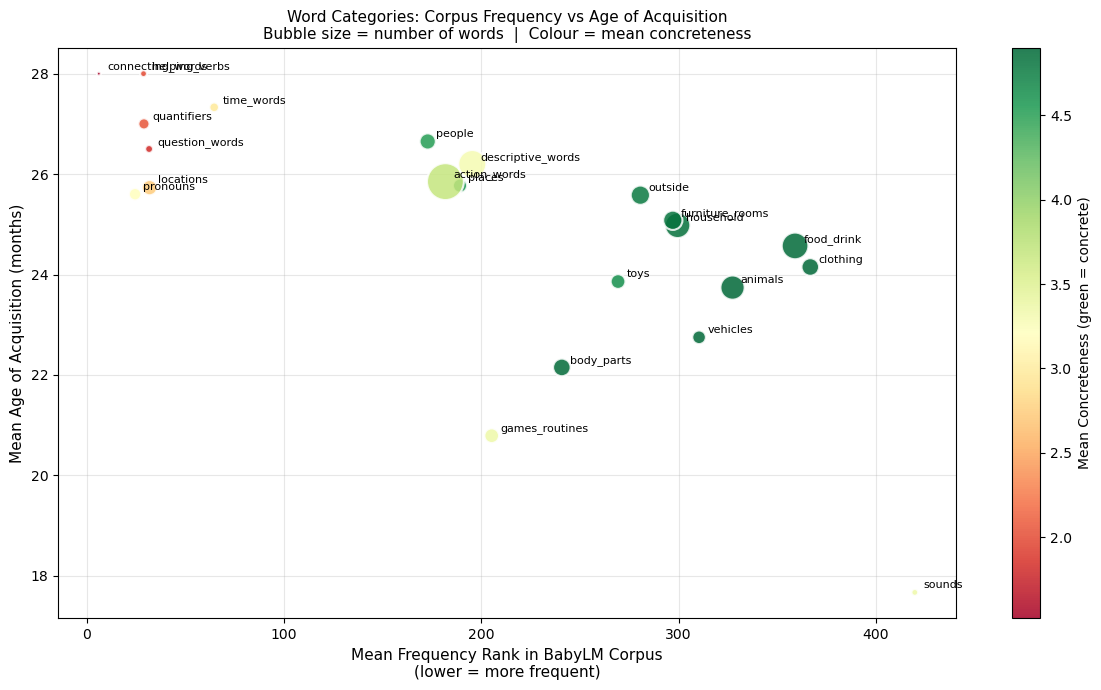

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    category_stats['mean_freq_rank'],
    category_stats['mean_aoa'],
    s=category_stats['n_words'] * 8,
    c=category_stats['mean_concrete'],
    cmap='RdYlGn', alpha=0.85,
    edgecolors='white', linewidth=1.5, zorder=3
)

for cat, row in category_stats.iterrows():
    ax.annotate(cat, (row['mean_freq_rank'], row['mean_aoa']),
               fontsize=8, ha='left',
               xytext=(6, 3), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='Mean Concreteness (green = concrete)')
ax.set_xlabel('Mean Frequency Rank in BabyLM Corpus\n(lower = more frequent)',
              fontsize=11)
ax.set_ylabel('Mean Age of Acquisition (months)', fontsize=11)
ax.set_title('Word Categories: Corpus Frequency vs Age of Acquisition\n'
             'Bubble size = number of words  |  Colour = mean concreteness',
             fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The category bubble chart represents things very vividly.

At the top left we have the categories that are frequent, but learned late - connecting_words, helping_verbs, pronouns, question_words, quantifiers. These categories host some of the most frequent words in child-directed speech ("I", "you", "what", "more", "because"), yet children tend to learn them late, since they are grammatical and abstract atnd learning them requires cognitive development that goes beyond just recognizing a sound pattern.

At the bottom right we have a category that is infrequent but learned early - sounds. Childlen learn "moo", "woof" and "vroom" very early, and yet these words almost never appear in the corpus. They are learned because they are fun and directly connected to things children care about, not because of their frequency.

The green concrete cluster in the middle right - animals, toys, food_drink, clothing, represents the categories where frequency and AoA roughly align. These are the words where the model's learning signal and the child's learning signal happen to point in the same direction.

# 7. Hypothesis Testing

## 7.1 Setup and Rationale
The category analysis in Section 6.4 suggests a clear pattern: abstract grammatical words show a much larger gap bewteen their frequency rank and their AoA rank than concrete object words do. In other words, frequency systematically underestimates how late abstract words are learned and underestimates how early concrete words are learned.

Here I formalize this observation as a hypothesis test.

The **rank gap** is defined for each word as:

$$
\text{rank gap} = \text{AoA rank} - \text{frequency rank}
$$

A positive rank gap means the word is learned later than its frequency would predict - the model would expect it to be learned early, but the children learn it late. A negative rank gap means the opposite - the word is learned earlier than its frequency would predict.

**Hypothesis**

$
H_0: \text{The rank gap distribution is the same for abstract grammatical words and concrete object words}
$

$
H_1: \text{Abstract grammatical words have a significantly larger rank gap than concrete object words}
$

## 7.2 The Mann-Whitney U Test
Because rank gap values are not normally distributed and the two groups are unequal in size (32 abstract vs 192 concrete words), I use the Mann-Whitney U test - a non-parametric test that compares the distribution of two independent groups without assuming normality. It tests whether values from one group tend to be larger than values from the other.

In [21]:
# Define categories
abstract_cats = ['pronouns', 'question_words', 'connecting_words',
                 'helping_verbs', 'quantifiers', 'time_words']
concrete_cats = ['animals', 'food_drink', 'clothing',
                 'body_parts', 'vehicles', 'toys', 'household']

# Compute rank gap
df_analysis['rank_gap'] = df_analysis['aoa_rank'] - df_analysis['freq_rank']

abstract_words = df_analysis[df_analysis['category'].isin(abstract_cats)]['rank_gap']
concrete_words = df_analysis[df_analysis['category'].isin(concrete_cats)]['rank_gap']

print(f"Abstract grammatical words : {len(abstract_words)}")
print(f"Concrete object words      : {len(concrete_words)}")
print(f"\nMean rank gap — abstract   : {abstract_words.mean():.1f}")
print(f"Mean rank gap — concrete   : {concrete_words.mean():.1f}")

stat, p = mannwhitneyu(abstract_words, concrete_words, alternative='greater')
print(f"\nMann-Whitney U statistic   : {stat:.1f}")
print(f"P-value                    : {p:.4f}")
print(f"\nResult: {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Abstract grammatical words : 32
Concrete object words      : 192

Mean rank gap — abstract   : 283.4
Mean rank gap — concrete   : -126.8

Mann-Whitney U statistic   : 6012.0
P-value                    : 0.0000

Result: Reject H₀ at α = 0.05


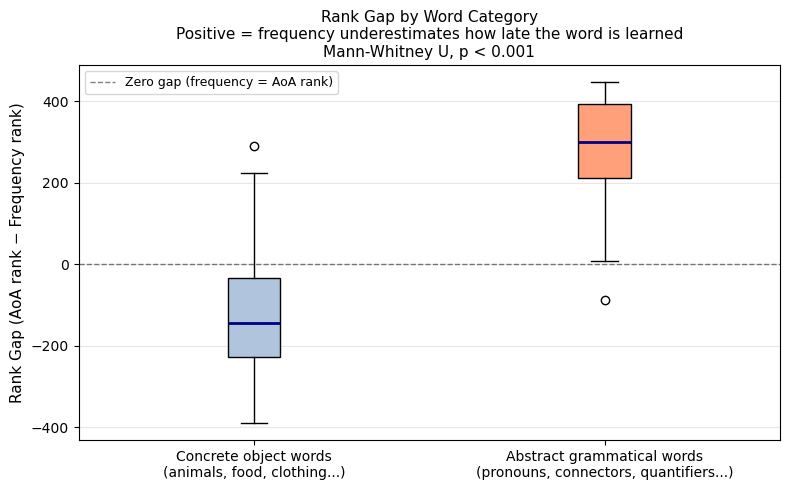

In [23]:
# Visualise rank gap distributions
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot([concrete_words.values, abstract_words.values],
                tick_labels=['Concrete object words\n(animals, food, clothing...)',
                        'Abstract grammatical words\n(pronouns, connectors, quantifiers...)'],
                patch_artist=True,
                medianprops=dict(color='navy', linewidth=2))

bp['boxes'][0].set_facecolor('lightsteelblue')
bp['boxes'][1].set_facecolor('lightsalmon')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label='Zero gap (frequency = AoA rank)')

ax.set_ylabel('Rank Gap (AoA rank − Frequency rank)', fontsize=11)
ax.set_title('Rank Gap by Word Category\n'
             'Positive = frequency underestimates how late the word is learned\n'
             'Mann-Whitney U, p < 0.001',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7.3 Interpretation
The test rejects $H_0$ with p < 0.001. The difference between the two groups is highly significant.

The mean rank gap for abstract grammatical words is +283.4 - these words are learned on average 283 ranking positions later than their frequency would predict. The mean rank gap for concrete object words is -126.8 - these words are learned on average 127 ranking positions earlier than their frequency would predict.

The boxplot makes this separation visually clear. The concrete box sits almost entirely below zero: frequency underestimates how early these words are learned and children learn them even earlier than the model would expect. The abstract box sits almost entirely above zero: frequency massively underestimates how late these words are learned - the model would predict them to be among the first learned but children learn them last.

This is not a small or ambiguous effect. It rather seems like a systematic and highly significant divergence between what a language model would predict and that what children actually do - concentrated exactly in the categories that require the most human cognitive development to acquire.

# 8. Discussion

## 8.1 Key Findings

The three datasets, the four correlation analyses and the one hypothesis test converge on the same conclusion. The results can be summarized as follows:

**Frequency predicts almost nothing.** The correlation between how often a word appears in child-directed speech and how early children learn it is r = -0.007, which is statistically indistinguishable from zero. A language model trained on the BabyLM corpus ranks words almost entirely by frequency. Children appear to ignore frequency almost entirely when deciding which words to learn first.

**Concreteness predicts significantly.** The strongest predictor of early word learning is how concrete a word is - whether it refers to something that can be touched, seen or pointed at. Concreteness (r = 0.302, p < 0.001) outperforms the corpus-derived measures. This is a human cognitive property and it appears that language models cannot directly access it from text alone.

**The gap is largest for abstract grammatical words.** Pronouns, connecting words, quantifiers and helping verbs are among the most frequent words in child-directed speech, yet children learn them last. The mean rank gap for these categories is +283.4 compared to -126.8 for concrete object words. This difference is highly significant (Mann-Whitney U, p < 0.001).

**Sound words are the most dramatic outlier**. Words like "moo", "woof" and "vroom" are almost invisible in the corpus, yet children learn them among the very first words. They are learned because they are embodied, playful and directly connected to things children find exciting. This is something that cannot be explained by frequency statistics. 

## 8.2 What the Gap Tells Us
The pattern that emerges from this analysis is consistent and interpretable. Children learn words that matter to them - words connected to what they can see and touch, words used in social routines, words that are fun to say. A language model learns words that appear frequently in text. These two criteria overlap for some words - common concrete nouns like "dog", "ball" and "cat" are both frequent and learned early. But for some categories of words they diverge completely and the divergence is not random. It is systematic and predictable - the more a word's meaning depends on embodied experience, social context or abstract cognitive development, the more the model's frequency based ranking fails.

This connects to a broader question in AI research. The BabyLM challenge was designed precisely to ask whether models trained on developmentally plausible data can learn language more like children do. The findings here suggest that the important thing is not the amount of data, it is the type. A model trained on ten million words of child directed speech still only has access to the statistical surface of language. It does not know what a cat smells like, what it feels like to fall or why "Mummy" is the most important word at eighteen months.

## 8.3 Limitations
The most important limitation is that frequency is only one of many signals available to a language model. Modern language models also learn from contextual patterns, syntactic structure and semantic cooccurence, none of which is captured by raw frequency alone. A more complete comparison could use model-derived surprisal scores or embedding distances rather than simple frequency counts.
This is most evident in the word sense disambiguation described in Section 5.4. Wordbank distinguishes between senses of the same word - "fish (food)" and "fish (animal)", "chicken (food)" and "chicken (animal)" that are represented by a single token in the corpus. The frequency counts therefore conflate two distinct concepts and the affected entries appear as missing from the analysis 

A second limitation is that the Wordbank data reflects parent report rather than direct observation and caregivers may be biased and over- or underreport certain words. The 16-30 month age window also means that words learned before 16 months or after 30 months are not captured. 

Finally, the Brysbaert concreteness ratings were collected from adult participants, not children. A child's sense of what is concrete may differ from an adult's. 

# 9. Conclusion

This project started, as my previous one did, with something I noticed at home. Children learn words in a particular order, and that order always seemed to me to have more to do with what matters to them than with how often they hear the words. This analysis confirms that intuition with data.

The results turned out to be clearer than I expected. Frequency, the learning signal that language models use, does not seem to predict anything about the order in which children learn words. Concreteness, a property of human cognition that language models cannot read directly from text, predicts significantly. The gap is largest precisely where you would expect it: abstract grammatical words that require social understanding and cognitive development, and embodied sound words that children learn because they are joyful and physical.

This gap does not mean that language models are failing. They are doing exactly what they are designed to do and they are actually doing it remarkably well given their constraints. It means that the gap between a child and a model is not primarily a gap in data quantity. It is a gap in the kind of information available. A child learns language while simultaniously learning about the world - through touch, emotion, social interaction and play. A model learns through the traces that the world leaves in text. Those traces are rich, but they are incomplete in specific predictable ways.

The BabyLM challenge is an honest attempt to close this gap by giving models the same data children get. This project suggests that the binding constraint, however, is not the data, but everything that happens outside the text.


# 10. References

### Datasets:

Wordbank: Frank, M.C., Braginsky, M., Yurovsky, D., & Marchman, V.A. (2017). Wordbank: An open repository for developmental vocabulary data. Journal of Child Language, 44(3), 677–694 (Available at: https://wordbank.stanford.edu, Accessed on 2026-03-28)


BabyLM Corpus: Warstadt, A., et al. (2023). Findings of the BabyLM Challenge: Sample-efficient pretraining on developmentally plausible corpora. In Proceedings of the BabyLM Challenge at CoNLL 2023. (Available on HuggingFace at: https://huggingface.co/nilq/babylm-10M, Accessed on 2026-03-28)


Brysbaert, M., Warriner, A.B., & Kuperman, V. (2014). Concreteness ratings for 40 thousand generally known English word lemmas. Behavior Research Methods, 46(3), 904–911 (Available at https://github.com/ArtsEngine/concreteness, Accessed on 2026-03-28)


### Background reading:

BabyLM Challenge 2024: Choshen, L., et al. (2024). The BabyLM Challenge 2024: Strict and strict-small tracks. Available at: https://babylm.github.io

Zipf, G.K. (1949). Human Behavior and the Principle of Least Effort. Addison-Wesley. Available at: https://archive.org/details/in.ernet.dli.2015.90211 